In [3]:
import os
import scipy.io as sio

folder_path = "NTU-Fi_HAR/train_amp/box"

for file in os.listdir(folder_path):
    if file.endswith(".mat"):
        mat = sio.loadmat(os.path.join(folder_path, file))
        
        print(f"\n📄 File: {file}")
        
        for key in mat:
            if not key.startswith("__"):
                print(f"{key} -> shape: {mat[key].shape}")
        
        break  # afficher un seul fichier


📄 File: box0.mat
CSIamp -> shape: (342, 2000)


In [4]:
import os

base_path = "NTU-Fi_HAR"
splits = ["train_amp", "test_amp"]

print("📊 Exploration du dataset NTU-Fi_HAR :")

for split in splits:
    split_path = os.path.join(base_path, split)
    if os.path.exists(split_path):
        print(f"\n📂 Dossier : {split}")
        # Lister uniquement les sous-dossiers (les classes)
        classes = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
        
        for cls in sorted(classes):
            class_path = os.path.join(split_path, cls)
            num_files = len([f for f in os.listdir(class_path) if f.endswith('.mat')])
            print(f"  - {cls.ljust(10)} : {num_files} fichiers .mat")
    else:
        print(f"Le dossier {split_path} est introuvable.")

📊 Exploration du dataset NTU-Fi_HAR :

📂 Dossier : train_amp
  - box        : 156 fichiers .mat
  - circle     : 156 fichiers .mat
  - clean      : 156 fichiers .mat
  - fall       : 156 fichiers .mat
  - run        : 156 fichiers .mat
  - walk       : 156 fichiers .mat

📂 Dossier : test_amp
  - box        : 44 fichiers .mat
  - circle     : 44 fichiers .mat
  - clean      : 44 fichiers .mat
  - fall       : 44 fichiers .mat
  - run        : 44 fichiers .mat
  - walk       : 44 fichiers .mat


In [5]:
import scipy.io as sio
import numpy as np

folder_path = "NTU-Fi_HAR/train_amp/box"
mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]

if mat_files:
    sample_file = mat_files[0]  # On prend le tout premier fichier
    file_path = os.path.join(folder_path, sample_file)
    mat_data = sio.loadmat(file_path)
    
    print(f"📄 Fichier inspecté : {sample_file}")
    print("-" * 40)
    
    data_key = None
    for key, value in mat_data.items():
        if not key.startswith("__"):
            print(f"🔑 Variable : '{key}' | Shape : {np.shape(value)}")
            # On suppose que la matrice avec la plus grande dimension contient le signal
            if isinstance(value, np.ndarray) and value.size > 1:
                data_key = key
                
    print(f"\n✅ Clé principale identifiée pour la visualisation : '{data_key}'")
else:
    print("Aucun fichier .mat trouvé dans ce répertoire.")

📄 Fichier inspecté : box0.mat
----------------------------------------
🔑 Variable : 'CSIamp' | Shape : (342, 2000)

✅ Clé principale identifiée pour la visualisation : 'CSIamp'


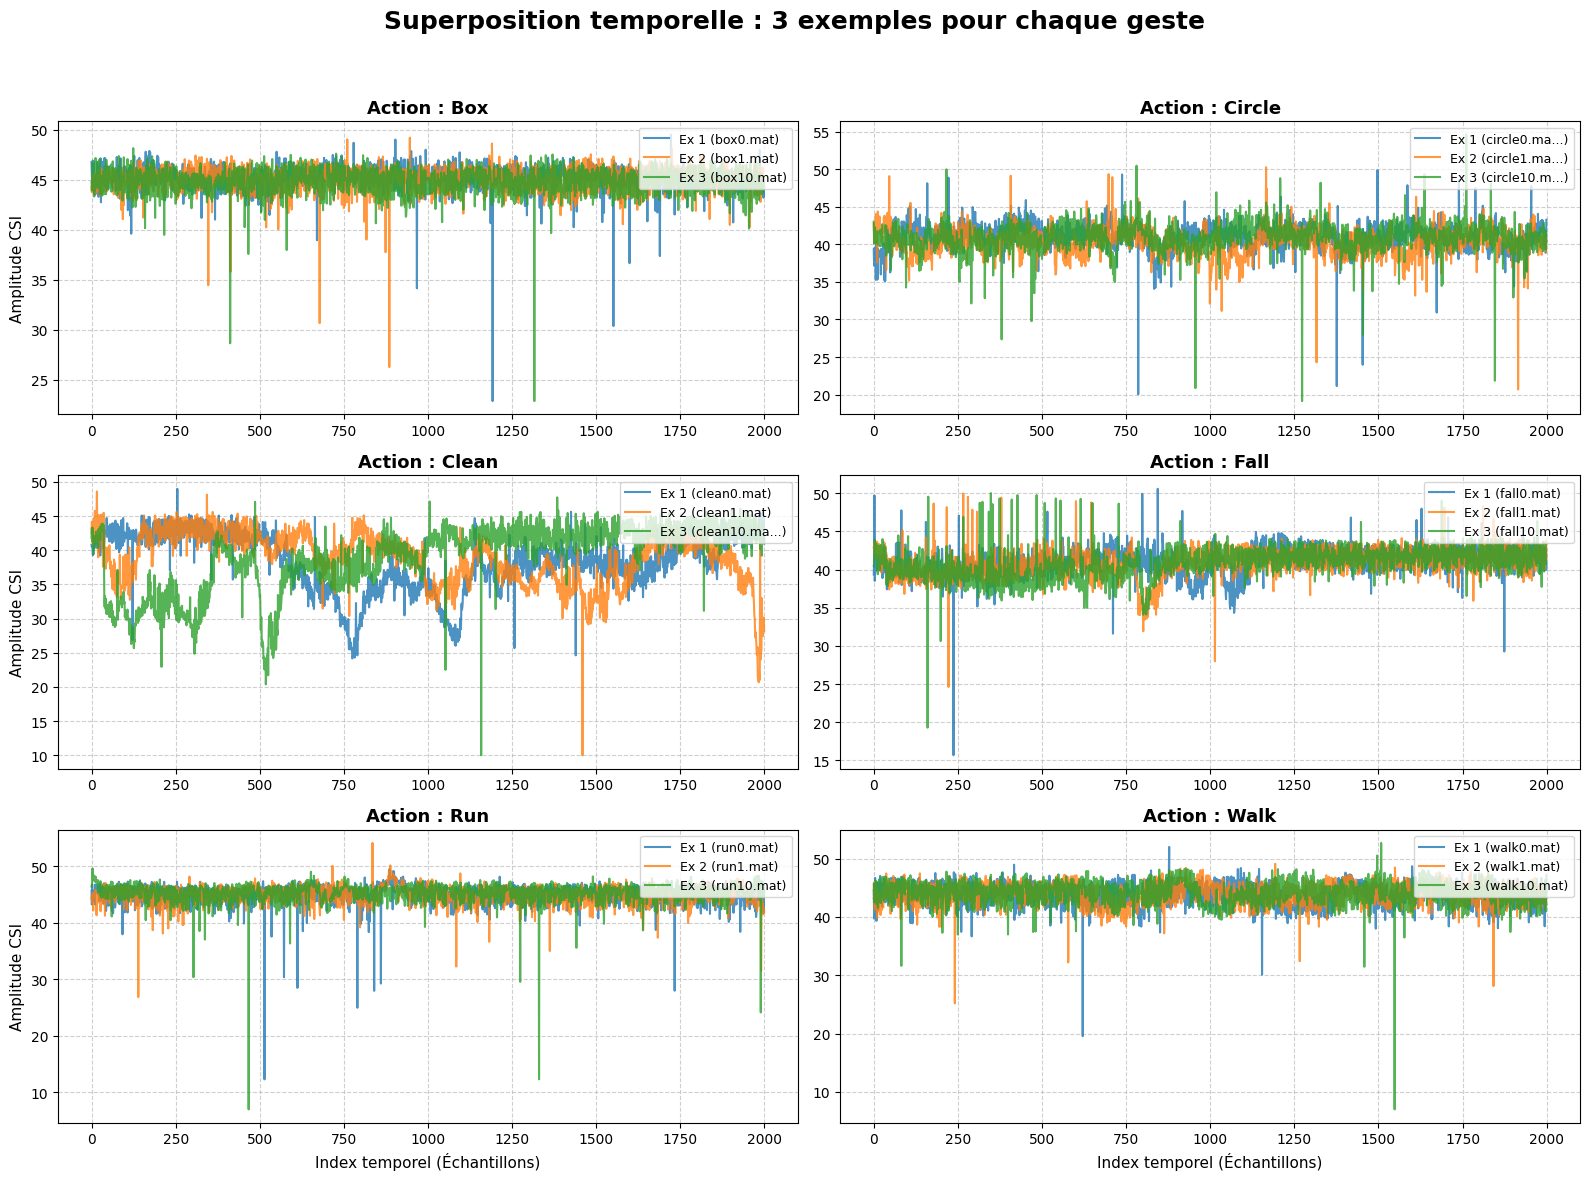

In [10]:
import os
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---
base_path = "NTU-Fi_HAR/train_amp"
gestures = ['box', 'circle', 'clean', 'fall', 'run', 'walk']
num_examples = 3
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Bleu, Orange, Vert

# Création d'une figure avec 6 sous-graphiques (3 lignes x 2 colonnes)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12))
fig.suptitle("Superposition temporelle : 3 exemples pour chaque geste", fontsize=18, fontweight='bold', y=0.98)

# Aplatir la matrice d'axes pour la parcourir facilement avec une simple boucle
axes = axes.flatten()

for i, gesture in enumerate(gestures):
    ax = axes[i]
    folder_path = os.path.join(base_path, gesture)
    
    ax.set_title(f"Action : {gesture.capitalize()}", fontsize=13, fontweight='bold')
    
    if os.path.exists(folder_path):
        mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
        
        # Parcourir jusqu'à 3 fichiers pour ce geste spécifique
        for j in range(min(num_examples, len(mat_files))):
            sample_file = mat_files[j]
            file_path = os.path.join(folder_path, sample_file)
            mat_data = sio.loadmat(file_path)
            
            # Identification automatique de la clé de données
            data_key = None
            for key, value in mat_data.items():
                if not key.startswith("__") and isinstance(value, np.ndarray) and value.size > 1:
                    data_key = key
                    break
                    
            if data_key:
                signal_data = mat_data[data_key]
                
                # Extraction du vecteur 1D
                if signal_data.ndim == 3:
                    time_series = signal_data[0, 0, :] 
                elif signal_data.ndim == 2:
                    time_series = signal_data[0, :]
                else:
                    time_series = signal_data.flatten()
                    
                # Raccourcir le nom du fichier pour ne pas surcharger la légende
                short_name = sample_file[:10] + "..." if len(sample_file) > 10 else sample_file
                
                # Tracé de la ligne superposée
                ax.plot(time_series, color=colors[j], linewidth=1.5, alpha=0.8, label=f'Ex {j+1} ({short_name})')

        # Mise en forme de chaque sous-graphique
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)
        
        # Afficher "Amplitude" uniquement sur la colonne de gauche (index pairs)
        if i % 2 == 0:
            ax.set_ylabel("Amplitude CSI", fontsize=11)
            
        # Afficher "Index temporel" uniquement sur la dernière ligne (les 2 derniers graphiques)
        if i >= 4: 
            ax.set_xlabel("Index temporel (Échantillons)", fontsize=11)
            
    else:
        ax.text(0.5, 0.5, f"Dossier introuvable:\n{folder_path}", ha='center', va='center')

# Ajustement de l'espacement global
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy import signal
from scipy.io import loadmat

# ==========================================
# 1. PRÉTRAITEMENT DES DONNÉES
# ==========================================

def butterworth_filter(data, cutoff=10, fs=200, order=5):
    """
    Applique un filtre passe-bas de Butterworth pour débruiter le signal CSI.
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = signal.filtfilt(b, a, data, axis=0)
    return filtered_data

def prepare_data(file_path, frame_size=750):
    """
    Charge le fichier .mat et segmente les données[cite: 128, 228].
    """
    data = loadmat(file_path)['CSIamp'] # Chargement de la clé CSIamp
    
    # 1. Dénoyage
    data_filtered = butterworth_filter(data)
    
    # 2. Normalisation
    data_norm = (data_filtered - np.mean(data_filtered)) / np.std(data_filtered)
    
    # 3. Segmentation (750 frames par échantillon) 
    # Note: Vos données font 2000 frames, nous extrayons ici les segments possibles
    segments = []
    for i in range(0, data_norm.shape[1] - frame_size + 1, 250): # Pas de 250
        segment = data_norm[:, i:i+frame_size]
        segments.append(segment)
        
    return torch.tensor(np.array(segments), dtype=torch.float32).unsqueeze(1) # Ajout dimension canal

# ==========================================
# 2. MODULES D'ATTENTION (CTSC-AB)
# ==========================================

class ChannelAttention(nn.Module):
    """
    Module d'attention sur les canaux[cite: 321, 328].
    """
    def __init__(self, in_planes, ratio=8):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        # MLP partagé [cite: 321, 330]
        self.mlp = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        out = avg_out + max_out # Somme des caractéristiques [cite: 328]
        return self.sigmoid(out)

class TimeSubcarrierAttention(nn.Module):
    """
    Module d'attention Temps-Sous-porteuse[cite: 331, 335].
    """
    def __init__(self, kernel_size=7):
        super(TimeSubcarrierAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pooling le long de l'axe des canaux [cite: 331]
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out) # Convolution 7x7 [cite: 337]
        return self.sigmoid(out)

# ==========================================
# 3. ARCHITECTURE LI-HAR
# ==========================================

class LI_HAR_Backbone(nn.Module):
    """
    CNN à 5 blocs avec mécanisme d'attention CTSC-AB[cite: 273, 282].
    """
    def __init__(self):
        super(LI_HAR_Backbone, self).__init__()
        
        # Exemple pour un bloc (à répéter 5 fois selon l'article [cite: 282])
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Bloc d'Attention CTSC-AB 
        self.ca1 = ChannelAttention(64)
        self.tsa = TimeSubcarrierAttention()
        self.ca2 = ChannelAttention(64)

    def forward(self, x):
        x = self.conv_block(x)
        
        # Séquence CTSC: Canal -> Temps-Sous-porteuse -> Canal [cite: 312]
        x = x * self.ca1(x)
        x = x * self.tsa(x)
        x = x * self.ca2(x)
        
        # Flatten pour le réseau prototypique
        return x.view(x.size(0), -1)

# ==========================================
# 4. RÉSEAU PROTOTYPIQUE (Few-Shot)
# ==========================================

def euclidean_dist(x, y):
    """
    Calcul de la distance euclidienne pour les prototypes[cite: 349].
    """
    n = x.size(0)
    m = y.size(0)
    d = x.size(1)
    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)
    return torch.pow(x - y, 2).sum(2)

class PrototypicalNet(nn.Module):
    def __init__(self, encoder):
        super(PrototypicalNet, self).__init__()
        self.encoder = encoder

    def forward(self, support_set, query_set, n_way, n_support, n_query):
        # 1. Extraction des caractéristiques
        support_embeddings = self.encoder(support_set)
        query_embeddings = self.encoder(query_set)
        
        # 2. Calcul des prototypes (moyenne des supports) [cite: 349]
        prototypes = support_embeddings.reshape(n_way, n_support, -1).mean(1)
        
        # 3. Distances et prédiction [cite: 349]
        distances = euclidean_dist(query_embeddings, prototypes)
        return F.log_softmax(-distances, dim=1)

# ==========================================
# 5. EXÉCUTION
# ==========================================

# Initialisation
backbone = LI_HAR_Backbone()
model = PrototypicalNet(backbone)

# Simulation de chargement
# data = prepare_data('box0.mat') 
# print(f"Shape des données prêtes: {data.shape}")